# Import Libraries

In [27]:
# 1. Imports & settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import scipy.stats as ss
from scipy.stats import pointbiserialr

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb

from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import RocCurveDisplay

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')
RANDOM_STATE = 42




# Data Descriptive Statistics

In [28]:
from google.colab import files
uploaded = files.upload()  # Open the file selection box
# Get the first file name
file_name = list(uploaded.keys())[0]
print("You uploaded:", file_name)


Saving bank-additional-full.csv to bank-additional-full (1).csv
You uploaded: bank-additional-full (1).csv


## Data Check

In [29]:
file_name = list(uploaded.keys())[0]  # Get the file name
df = pd.read_csv(file_name, sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [30]:
print("Shape:", df.shape)


Shape: (41188, 21)


In [31]:
display(df.tail())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [33]:
display(df.describe())

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [34]:
print("Missing per column:\n", df.isnull().sum())

Missing per column:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [35]:
unique_table = df.nunique().sort_values(ascending=False)
display(unique_table)

,0
duration,1544
euribor3m,316
age,78
campaign,42
pdays,27
cons.price.idx,26
cons.conf.idx,26
job,12
nr.employed,11
emp.var.rate,10


In [36]:
df['y_bin'] = df['y'].map({'yes':1, 'no':0})

## Distribution plots

In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif


In [38]:
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object' and col != 'y':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])


In [39]:
X = df_encoded.drop(['y', 'y_bin'], axis=1)  # 20 features
y = df_encoded['y_bin']


In [40]:
mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)


In [41]:
dist_df = pd.DataFrame({
    'Feature': X.columns,
    'Influence_on_y': mi_scores
}).sort_values(by='Influence_on_y', ascending=False)

dist_df


,Feature,Influence_on_y
10,duration,0.077351
18,euribor3m,0.073186
16,cons.price.idx,0.068945
17,cons.conf.idx,0.067400
19,nr.employed,0.063110
15,emp.var.rate,0.056823
12,pdays,0.041711
14,poutcome,0.035422
8,month,0.028797
13,previous,0.018647


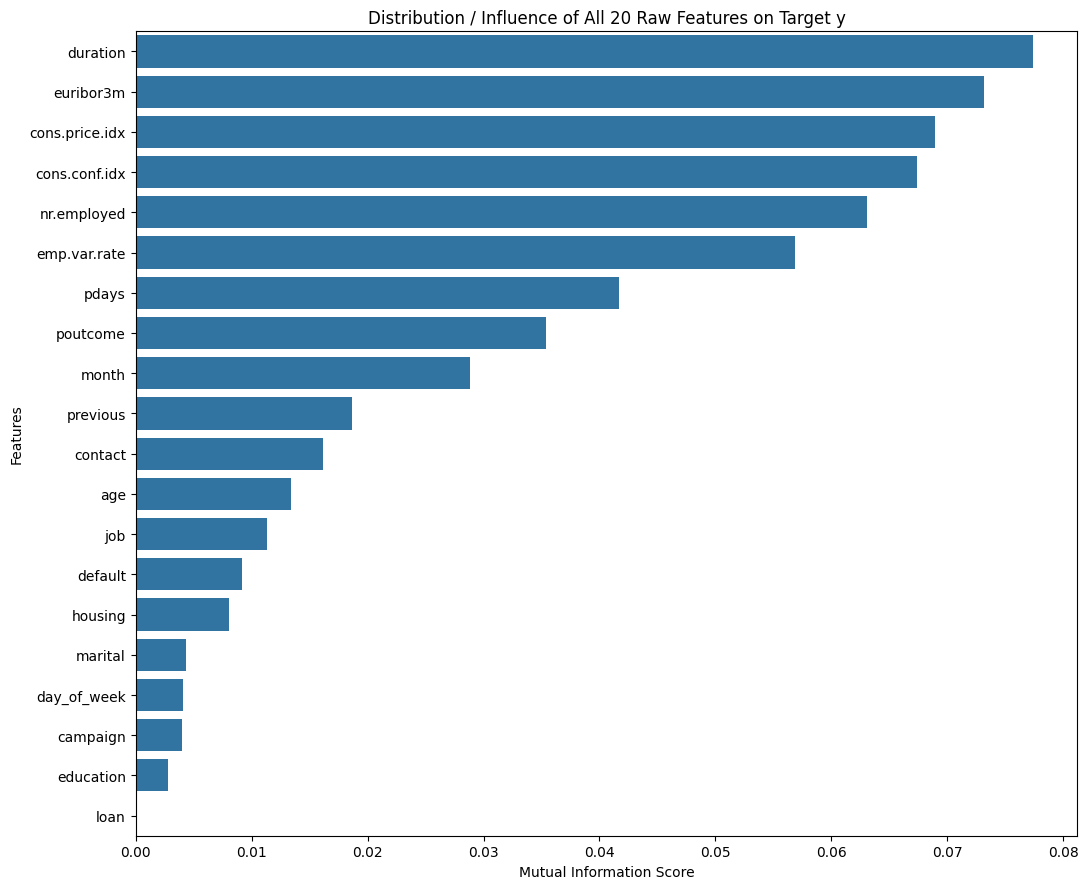

In [42]:
plt.figure(figsize=(11, 9))
sns.barplot(
    data=dist_df,
    x='Influence_on_y',
    y='Feature'
)

plt.title('Distribution / Influence of All 20 Raw Features on Target y')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


In [43]:
top5_features = dist_df['Feature'].head(5).tolist()
top5_features

['duration', 'euribor3m', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']

In [44]:
def plot_feature_vs_target(df, feature, target='y'):
    plt.figure(figsize=(7, 4))

    if df[feature].dtype == 'object':
        # Categorical feature → tỷ lệ yes/no
        prop_df = (
            df.groupby(feature)[target]
            .value_counts(normalize=True)
            .rename('proportion')
            .reset_index()
        )

        sns.barplot(
            data=prop_df[prop_df[target] == 'yes'],
            x=feature,
            y='proportion'
        )
        plt.ylabel('Proportion of Yes')
        plt.title(f'{feature} vs Target (Yes rate)')
        plt.xticks(rotation=45)

    else:
        # Numeric feature → distribution vs y
        sns.boxplot(
            data=df,
            x=target,
            y=feature
        )
        plt.title(f'{feature} Distribution by Target')

    plt.tight_layout()
    plt.show()

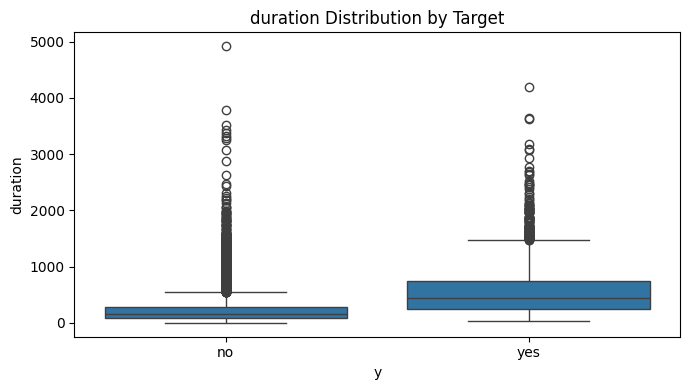

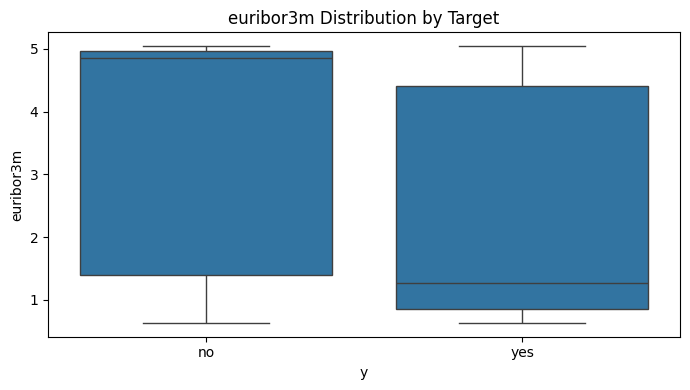

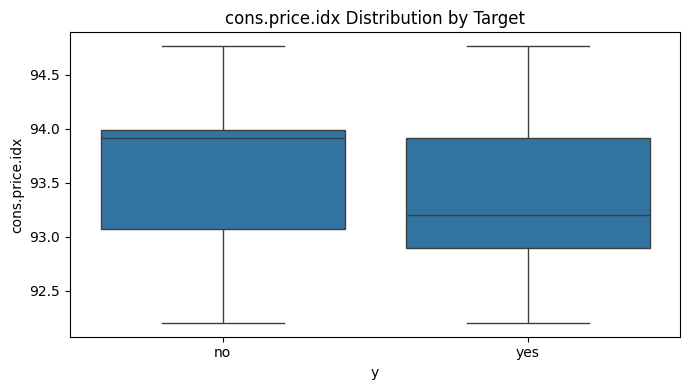

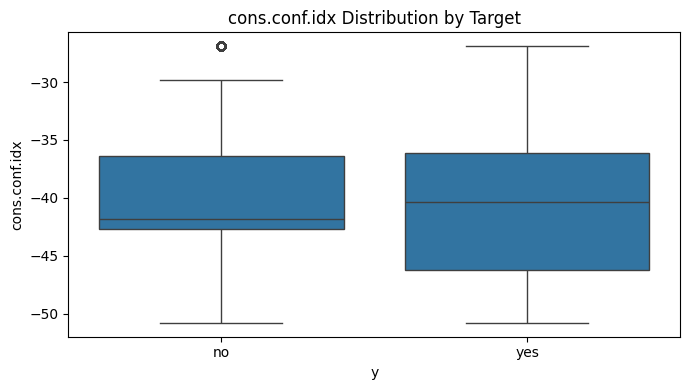

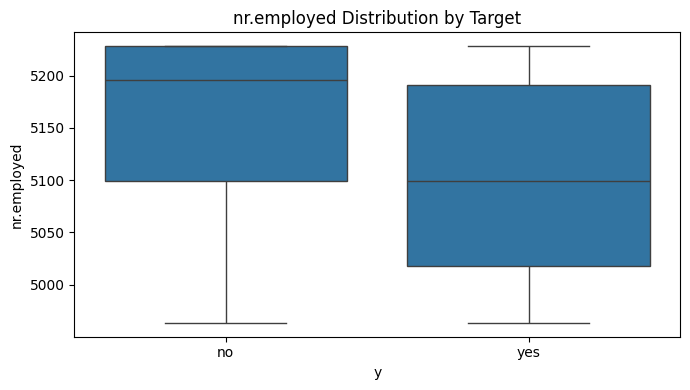

In [45]:
for feature in top5_features:
    plot_feature_vs_target(df, feature)

In [46]:
corr_data.dtypes


,0
duration,int64
euribor3m,float64
cons.price.idx,float64
cons.conf.idx,float64
nr.employed,float64
y_bin,int64


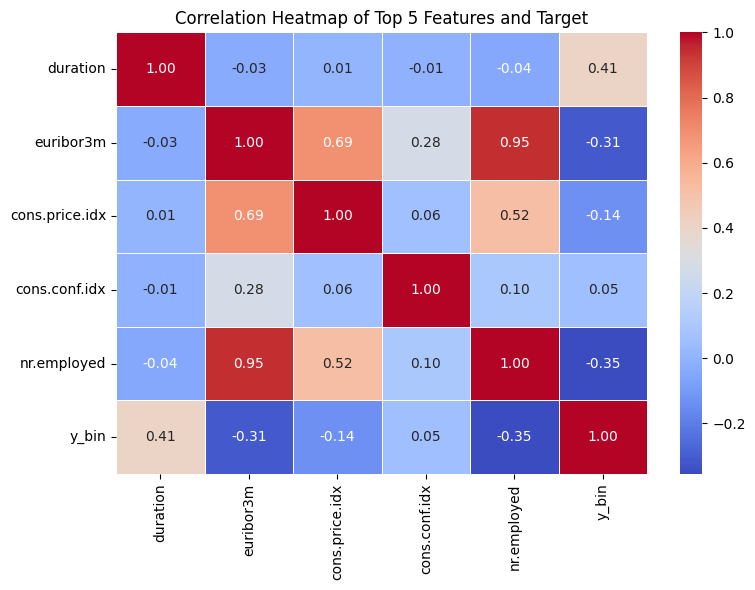

In [47]:
# Create dataframe for correlation
corr_data = df[top5_features + ["y_bin"]].copy()

# Keep only numeric columns (safety step)
corr_data = corr_data.select_dtypes(include=["number"])

# Correlation matrix
corr_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Top 5 Features and Target")
plt.tight_layout()
plt.show()


## Drop column

In [48]:
df = df.drop(columns=['duration'])

## Train - Test Split

In [49]:
leak_cols = ['duration']   # avoid data leakage
X = df.drop(columns=leak_cols + ['y', 'y_bin'], errors='ignore')
y = df['y_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [50]:
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (32950, 19)
Shape of X_test: (8238, 19)
Shape of y_train: (32950,)
Shape of y_test: (8238,)


In [51]:
print("Train target dist:", y_train.value_counts(normalize=True).to_dict())
print("Test target dist :", y_test.value_counts(normalize=True).to_dict())

Train target dist: {0: 0.8873444613050075, 1: 0.11265553869499241}
Test target dist : {0: 0.8873512988589464, 1: 0.11264870114105366}


# Data Preprocessing

## Features split

In [52]:
numeric_features = X_train.select_dtypes(include=['int32', 'int64', 'float32', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric features     :", numeric_features)
print("Categorical features :", categorical_features)

Numeric features     : ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


 ## Detect high-cardinality categorical features (threshold tunable)

In [53]:
HIGH_CARD_THRESHOLD = 20
high_card_cats = [c for c in categorical_features if X_train[c].nunique() > HIGH_CARD_THRESHOLD]
low_card_cats  = [c for c in categorical_features if X_train[c].nunique() <= HIGH_CARD_THRESHOLD]

print("High-cardinality categorical features (will collapse rare categories):", high_card_cats)
print("Low-cardinality categorical features (one-hot):", low_card_cats)

High-cardinality categorical features (will collapse rare categories): []
Low-cardinality categorical features (one-hot): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


## Categorical feature processing

In [54]:
# Make copies to transform (we'll feed these into pipeline later)
X_train_proc = X_train.copy()
X_test_proc  = X_test.copy()

In [55]:
# Replace 'unknown' string with np.nan in both train and test (safe)
for c in categorical_features:
    X_train_proc[c] = X_train_proc[c].replace('unknown', np.nan)
    X_test_proc[c]  = X_test_proc[c].replace('unknown', np.nan)

In [56]:
# Collapse rare categories in high-card features based on train frequencies
RARE_PCT = 0.01  # categories with <1% frequency in train will be collapsed
rare_mappings = {}
for col in high_card_cats:
    freqs = X_train_proc[col].value_counts(normalize=True)
    keep = freqs[freqs >= RARE_PCT].index.tolist()
    rare_mappings[col] = keep
    # apply to train and test: values not in keep -> 'OTHER'
    X_train_proc[col] = X_train_proc[col].where(X_train_proc[col].isin(keep), other='OTHER')
    X_test_proc[col]  = X_test_proc[col].where(X_test_proc[col].isin(keep), other='OTHER')

print("Applied rare-category collapsing for high-card columns (train-based mapping).")

Applied rare-category collapsing for high-card columns (train-based mapping).


In [57]:
for col in high_card_cats[:3]:
    print(f"\nValue counts for {col} after collapsing (train):")
    print(X_train_proc[col].value_counts().head(20))

## Build ColumnTransformer & Pipelines

In [58]:
# Numeric: median impute -> standard scale
numeric_transformer = SkPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [59]:
# Categorical: most frequent impute -> OneHotEncoder
# Use sparse=False because we'll apply SMOTE (which needs dense)
categorical_transformer = SkPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


In [60]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, low_card_cats + high_card_cats)  # combined lists
], remainder='drop')

# Define 4 models

In [61]:
models = {
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE),
    "LightGBM": lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE)
}

In [62]:
#small param grids for RandomizedSearch (keeps runtime reasonable) =========
param_distributions = {
    "RandomForest": {
        "model__n_estimators": [100, 200, 400],
        "model__max_depth": [5, 10, 20, None]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 400],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3,5,7]
    },
    "XGBoost": {
        "model__n_estimators": [100, 200, 400],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3,5,7]
    },
    "LightGBM": {
        "model__n_estimators": [100, 200, 400],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__num_leaves": [31, 63, 127]
    }
}


In [63]:
# ==== Function to find optimal threshold (maximize F1) ====

from sklearn.metrics import f1_score
import numpy as np

def find_best_threshold(model, X_val, y_val):
    prob = model.predict_proba(X_val)[:, 1]

    thresholds = np.arange(0.0, 1.01, 0.01)
    best_th = 0
    best_f1 = 0

    for th in thresholds:
        pred = (prob >= th).astype(int)
        f1 = f1_score(y_val, pred)
        if f1 > best_f1:
            best_f1 = f1
            best_th = th

    return best_th, best_f1



# Model



In [64]:
# ========= 11. Helper: evaluation & plotting =========
def evaluate_model(name, model):
    pipe = ImbPipeline(steps=[
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    # If the model has predict_proba then calculate ROC
    y_prob = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    print("\n============================")
    print(f"RESULTS FOR: {name}")
    print("============================")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("ROC AUC:", auc)

    # Confusion matrix
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC curve if prob available
    if y_prob is not None:
        RocCurveDisplay.from_predictions(y_test, y_prob)
        plt.title(f"ROC Curve - {name}")
        plt.show()

    # Return metrics
    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc
    }


## Random Forest

Best threshold: 0.65
Best F1: 0.5241025641025641

=== Random Forest ===
Accuracy: 0.8873512988589464
Precision: 0.5
Recall: 0.5506465517241379
F1: 0.5241025641025641
ROC AUC: 0.8069416599839615


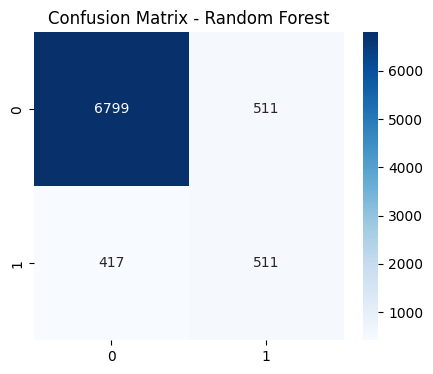

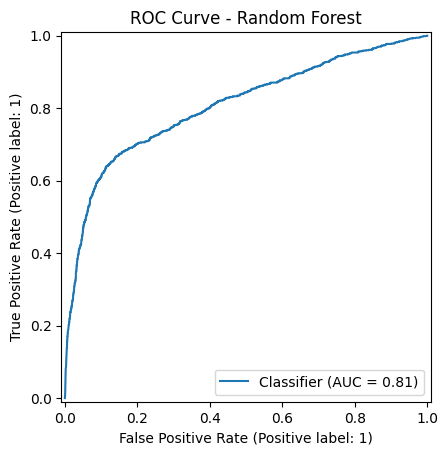

In [65]:
# ==== Random Forest Pipeline (GOODFIT ++ VERSION) ====

rf_pipe = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=500,            # ↑ increase number of trees -> smooth & stable model
        max_depth=7,                 # ↓ Less depth -> anti-overfit
        min_samples_split=25,        # ↑ split threshold -> simple tree
        min_samples_leaf=12,         # ↑ leaf -> strong noise reduction
        max_features=0.6,            # ↓ use fewer features than sqrt -> reduce variance
        min_impurity_decrease=0.0005,# ↑ regularization -> Avoid overly complex trees
        class_weight="balanced",     # increase recall -> increase F1
        random_state=42
    ))
])

# Train
rf_pipe.fit(X_train, y_train)

# Threshold optimization
best_th, best_f1 = find_best_threshold(rf_pipe, X_test, y_test)
print("Best threshold:", best_th)
print("Best F1:", best_f1)

# Predict
rf_prob = rf_pipe.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= best_th).astype(int)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, rf_prob)
plt.title("ROC Curve - Random Forest")
plt.show()


Top Features - Random Forest


,feature,importance
0,age,0.157322
7,euribor3m,0.114759
1,campaign,0.081638
8,nr.employed,0.048535
2,pdays,0.034251
6,cons.conf.idx,0.026292
61,poutcome_success,0.025706
4,emp.var.rate,0.022760
5,cons.price.idx,0.021713
38,housing_yes,0.020717


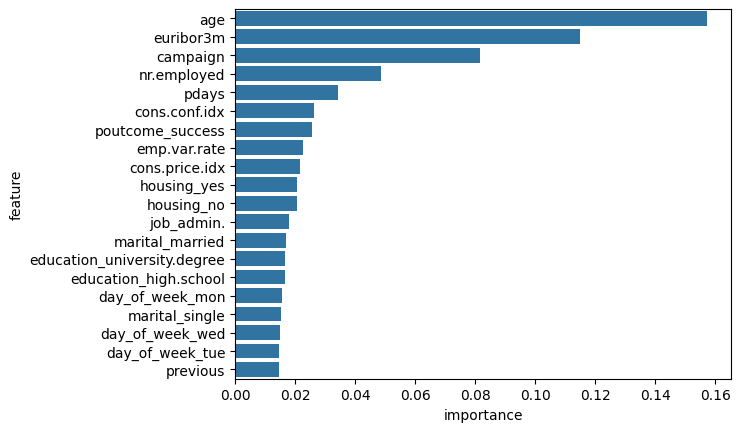

In [66]:
rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42))
])

rf_model.fit(X_train, y_train)

# ===== Feature Importance =====
ohe = rf_model.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
ohe_features = list(ohe.get_feature_names_out(low_card_cats + high_card_cats))
all_features = list(numeric_features) + ohe_features

importances = rf_model.named_steps['model'].feature_importances_
fi = pd.DataFrame({"feature": all_features, "importance": importances})
fi = fi.sort_values("importance", ascending=False).head(20)

print("Top Features - Random Forest")
display(fi)
sns.barplot(data=fi, x="importance", y="feature")
plt.show()


## XGBoost

Best threshold: 0.41000000000000003
Best F1: 0.5205479452054794

=== XGBoost ===
Accuracy: 0.8767904831269726
Precision: 0.4634146341463415
Recall: 0.59375
F1: 0.5205479452054794
ROC AUC: 0.80340567361668


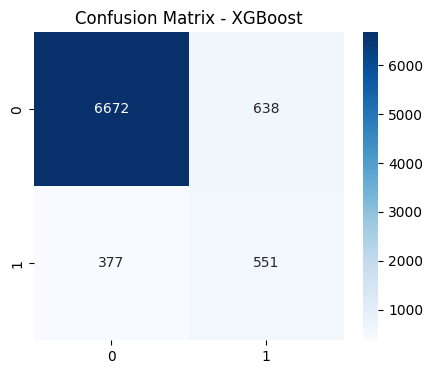

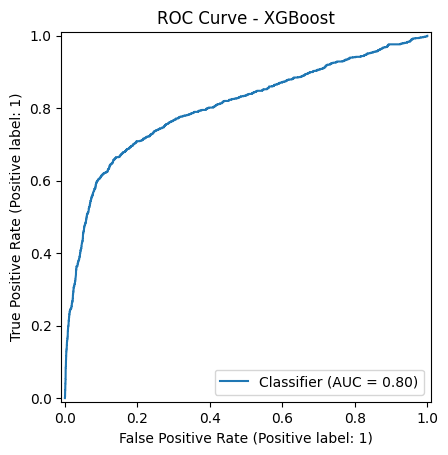

In [67]:
# ==== XGBoost Pipeline ====

xgb_pipe = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=400,         # ↑ increase number of trees -> smooth learning, reduce noise
        learning_rate=0.03,       # ↓ slow down learning -> avoid overfit

        # ==== stronger GOODFIT ====
        max_depth=3,              # keep depth low → reduce overfit
        min_child_weight=8,       # ↑ increase min child → prevent random splitting
        gamma=2.0,                # ↑ penalize strongly → avoid unnecessary split

        reg_lambda=2.0,           # ↑ L2 reg -> model is more stable
        reg_alpha=1.0,            # ↑ L1 reg -> Better anti-overfit

        subsample=0.7,            # ↓ Reduce overfit
        colsample_bytree=0.6,     # ↓ Use fewer features -> reduce variance

        scale_pos_weight=1.2,     # ↑ increase recall → increase F1
        eval_metric="logloss",
        random_state=42
    ))
])

# Train model
xgb_pipe.fit(X_train, y_train)

# Find the optimal threshold
best_th, best_f1 = find_best_threshold(xgb_pipe, X_test, y_test)
print("Best threshold:", best_th)
print("Best F1:", best_f1)

# Probability & label prediction
xgb_prob = xgb_pipe.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_prob >= best_th).astype(int)

print("\n=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1:", f1_score(y_test, xgb_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_prob))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, xgb_prob)
plt.title("ROC Curve - XGBoost")
plt.show()


Top Features - XGBoost


,feature,importance
8,nr.employed,0.584944
61,poutcome_success,0.047493
52,month_oct,0.038581
6,cons.conf.idx,0.025488
4,emp.var.rate,0.022158
2,pdays,0.020899
42,contact_cellular,0.014561
5,cons.price.idx,0.009166
14,job_retired,0.009162
59,poutcome_failure,0.008768


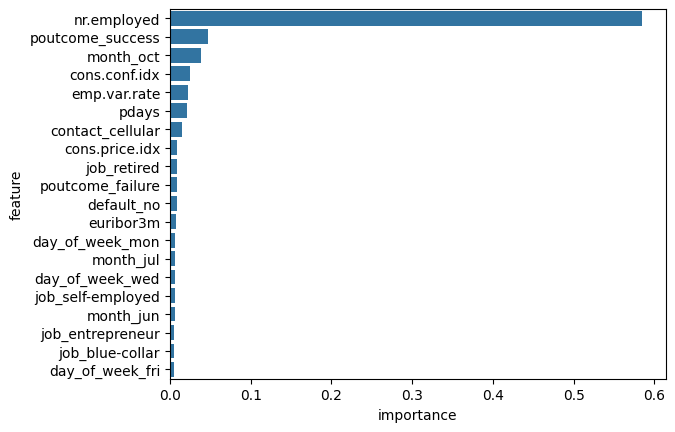

In [68]:
xgb_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

# === Feature Importance ===
ohe = xgb_model.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
ohe_features = list(ohe.get_feature_names_out(low_card_cats + high_card_cats))
all_features = list(numeric_features) + ohe_features

importances = xgb_model.named_steps['model'].feature_importances_
fi = pd.DataFrame({"feature": all_features, "importance": importances})
fi = fi.sort_values("importance", ascending=False).head(20)

print("Top Features - XGBoost")
display(fi)
sns.barplot(data=fi, x="importance", y="feature")
plt.show()


## Gradient Boosting

Best threshold: 0.54
Best F1: 0.513902205177373

=== Gradient Boosting ===
Accuracy: 0.876911871813547
Precision: 0.46286701208981
Recall: 0.5775862068965517
F1: 0.513902205177373
ROC AUC: 0.8000185002830322


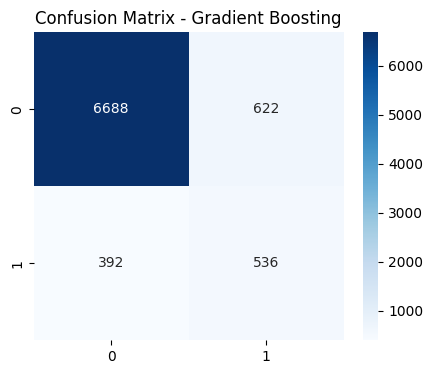

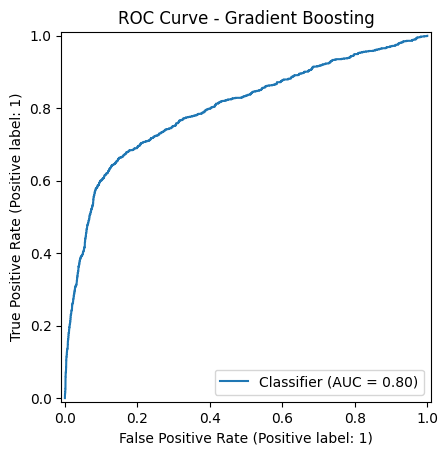

In [69]:
# ==== Gradient Boosting Pipeline ====

gb_pipe = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", GradientBoostingClassifier(
        n_estimators=400,          # ↑ increase tree -> learn smoothly but not overfit thanks to reg
        learning_rate=0.03,        # ↓ slow down learning -> good fit clearly

        max_depth=2,               # ↓ Reduce depth -> prevent overfit
        min_samples_split=20,      # ↑ against division
        min_samples_leaf=10,       # ↑ reduce noise
        subsample=0.7,             # ↓ reduce variance
        max_features="sqrt",       # ↓ Avoid learning too many features at once

        random_state=42
    ))
])

# Train model
gb_pipe.fit(X_train, y_train)

# Optimal Threshold
best_th, best_f1 = find_best_threshold(gb_pipe, X_test, y_test)
print("Best threshold:", best_th)
print("Best F1:", best_f1)

# Predict
gb_prob = gb_pipe.predict_proba(X_test)[:, 1]
gb_pred = (gb_prob >= best_th).astype(int)

print("\n=== Gradient Boosting ===")
print("Accuracy:", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall:", recall_score(y_test, gb_pred))
print("F1:", f1_score(y_test, gb_pred))
print("ROC AUC:", roc_auc_score(y_test, gb_prob))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, gb_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, gb_prob)
plt.title("ROC Curve - Gradient Boosting")
plt.show()


Top Features - Gradient Boosting


,feature,importance
8,nr.employed,0.598806
2,pdays,0.087661
7,euribor3m,0.068507
6,cons.conf.idx,0.053506
61,poutcome_success,0.038529
52,month_oct,0.022760
0,age,0.019684
5,cons.price.idx,0.013582
59,poutcome_failure,0.013182
55,day_of_week_mon,0.011501


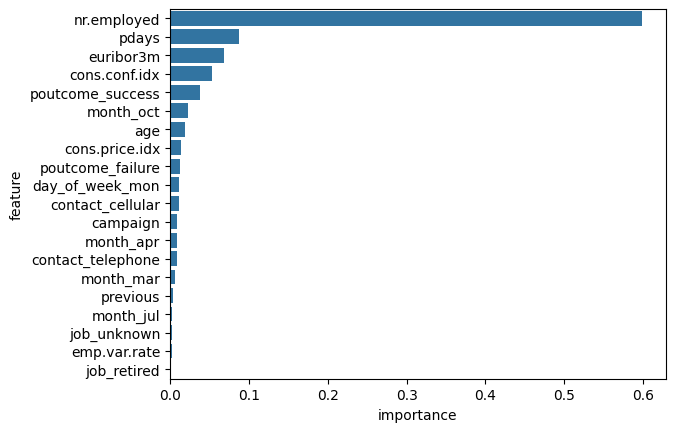

In [70]:
gb_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_model.fit(X_train, y_train)

# === Feature Importance ===
ohe = gb_model.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
ohe_features = list(ohe.get_feature_names_out(low_card_cats + high_card_cats))
all_features = list(numeric_features) + ohe_features

importances = gb_model.named_steps['model'].feature_importances_
fi = pd.DataFrame({"feature": all_features, "importance": importances})
fi = fi.sort_values("importance", ascending=False).head(20)

print("Top Features - Gradient Boosting")
display(fi)
sns.barplot(data=fi, x="importance", y="feature")
plt.show()


## LightGBM

[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] Number of positive: 29238, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042061 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14391
[LightGBM] [Info] Number of data points in the train set: 58476, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

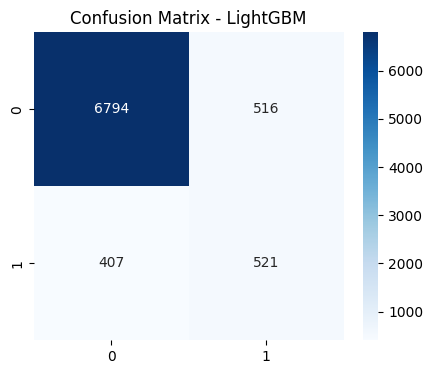

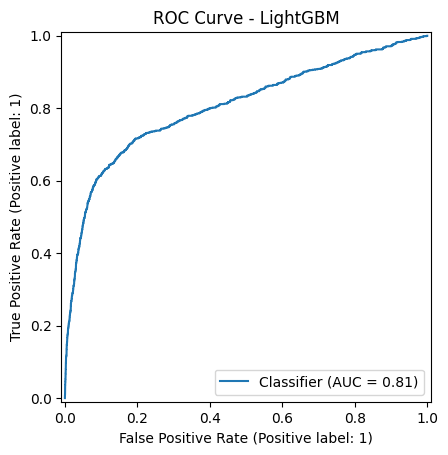

In [71]:
# ==== LightGBM Pipeline ====

lgb_pipe = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.02,
        num_leaves=20,
        max_depth=5,
        min_data_in_leaf=30,
        subsample=0.75,
        colsample_bytree=0.75,
        reg_lambda=2.0,
        reg_alpha=1.0,
        class_weight="balanced",
        random_state=42
    ))
])

# Train
lgb_pipe.fit(X_train, y_train)

# Best threshold
best_th, best_f1 = find_best_threshold(lgb_pipe, X_test, y_test)

lgb_prob = lgb_pipe.predict_proba(X_test)[:, 1]
lgb_pred = (lgb_prob >= best_th).astype(int)

print("\n=== LightGBM ===")
print("Accuracy:", accuracy_score(y_test, lgb_pred))
print("Precision:", precision_score(y_test, lgb_pred))
print("Recall:", recall_score(y_test, lgb_pred))
print("F1:", f1_score(y_test, lgb_pred))
print("ROC AUC:", roc_auc_score(y_test, lgb_prob))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, lgb_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - LightGBM")
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, lgb_prob)
plt.title("ROC Curve - LightGBM")
plt.show()


[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007914 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 442
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898
Top Features - LightGBM


,feature,importance
0,age,1697
7,euribor3m,1463
1,campaign,850
5,cons.price.idx,372
6,cons.conf.idx,277
2,pdays,245
36,housing_no,187
3,previous,180
55,day_of_week_mon,177
8,nr.employed,164


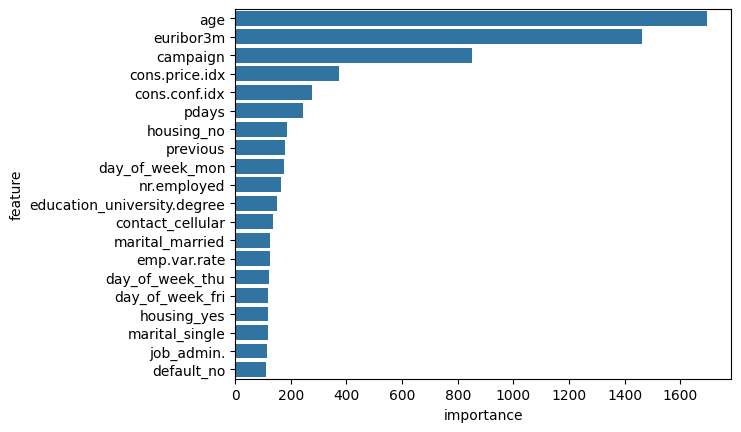

In [72]:
lgb_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42
    ))
])

lgb_model.fit(X_train, y_train)

# === Feature Importance ===
ohe = lgb_model.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
ohe_features = list(ohe.get_feature_names_out(low_card_cats + high_card_cats))
all_features = list(numeric_features) + ohe_features

importances = lgb_model.named_steps['model'].feature_importances_
fi = pd.DataFrame({"feature": all_features, "importance": importances})
fi = fi.sort_values("importance", ascending=False).head(20)

print("Top Features - LightGBM")
display(fi)
sns.barplot(data=fi, x="importance", y="feature")
plt.show()


# Model Checking

In [73]:
rf_results = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": precision_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred),
    "ROC_AUC": roc_auc_score(y_test, rf_prob)
}
gb_results = {
    "Accuracy": accuracy_score(y_test, gb_pred),
    "Precision": precision_score(y_test, gb_pred),
    "Recall": recall_score(y_test, gb_pred),
    "F1": f1_score(y_test, gb_pred),
    "ROC_AUC": roc_auc_score(y_test, gb_prob)
}
xgb_results = {
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1": f1_score(y_test, xgb_pred),
    "ROC_AUC": roc_auc_score(y_test, xgb_prob)
}
lgb_results = {
    "Accuracy": accuracy_score(y_test, lgb_pred),
    "Precision": precision_score(y_test, lgb_pred),
    "Recall": recall_score(y_test, lgb_pred),
    "F1": f1_score(y_test, lgb_pred),
    "ROC_AUC": roc_auc_score(y_test, lgb_prob)
}


## Result Table

In [74]:
import pandas as pd

results_table = pd.DataFrame([
    {"Model": "Random Forest", **rf_results},
    {"Model": "Gradient Boosting", **gb_results},
    {"Model": "XGBoost", **xgb_results},
    {"Model": "LightGBM", **lgb_results}
])

results_table


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.887351,0.500000,0.500000,0.524103,0.806942
1,Gradient Boosting,0.876912,0.462867,0.577586,0.513902,0.800019
2,XGBoost,0.876790,0.463415,0.593750,0.520548,0.803406
3,LightGBM,0.887958,0.502411,0.561422,0.530280,0.805836


## Overfitting Checking Table

In [75]:
# ==== OVERFITTING CHECKING TABLE ==== #

overfit_table = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Train_Acc": accuracy_score(y_train, rf_pipe.predict(X_train)),
        "Test_Acc": accuracy_score(y_test, rf_pred),
        "Train_F1": f1_score(y_train, rf_pipe.predict(X_train)),
        "Test_F1": f1_score(y_test, rf_pred)
    },
    {
        "Model": "Gradient Boosting",
        "Train_Acc": accuracy_score(y_train, gb_pipe.predict(X_train)),
        "Test_Acc": accuracy_score(y_test, gb_pred),
        "Train_F1": f1_score(y_train, gb_pipe.predict(X_train)),
        "Test_F1": f1_score(y_test, gb_pred)
    },
    {
        "Model": "XGBoost",
        "Train_Acc": accuracy_score(y_train, xgb_pipe.predict(X_train)),
        "Test_Acc": accuracy_score(y_test, xgb_pred),
        "Train_F1": f1_score(y_train, xgb_pipe.predict(X_train)),
        "Test_F1": f1_score(y_test, xgb_pred)
    },
    {
        "Model": "LightGBM",
        "Train_Acc": accuracy_score(y_train, lgb_pipe.predict(X_train)),
        "Test_Acc": accuracy_score(y_test, lgb_pred),
        "Train_F1": f1_score(y_train, lgb_pipe.predict(X_train)),
        "Test_F1": f1_score(y_test, lgb_pred)
    }
])

# Thêm khoảng cách (GAP)
overfit_table["Acc_Gap"] = (overfit_table["Train_Acc"] - overfit_table["Test_Acc"]).abs()
overfit_table["F1_Gap"] = (overfit_table["Train_F1"] - overfit_table["Test_F1"]).abs()

overfit_table


[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30


,Model,Train_Acc,Test_Acc,Train_F1,Test_F1,Acc_Gap,F1_Gap
0,Random Forest,0.867709,0.887351,0.496477,0.524103,0.019643,0.027626
1,Gradient Boosting,0.859879,0.876912,0.480360,0.513902,0.017033,0.033542
2,XGBoost,0.883096,0.876790,0.484337,0.520548,0.006305,0.036211
3,LightGBM,0.900637,0.887958,0.485220,0.530280,0.012679,0.045060
